# Lab 1 DS & AI - DQ
# Influence of Data Quality on Machine Learning performance

**Group:** _8_ 

**Names / student numbers:** 

_Luís Forti - 3981932_

_Marcell Slyuch - 3992616_

_Ntando Thato Mazinyane - 3987639_

In this lab we will explore different data quality problems and their possible effect on classification or regression tasks. To help you to start quickly with this lab, the notebook below already implements a basic Regression and Classification task. You can do the exercises by taking this code and modify/extend it. 

## Import Relevant Libraries

In [1]:
# Uncomment if needed and restart the Kernel after installation
# %pip install seaborn
# %pip install scipy
# %pip install scikit-learn

In [2]:
# If you get an error on the import of the seaborn package below, then you need to install
# it first with 'pip' in the above box. Uncomment the '%pip' line, execute the cell, comment it again,
# and do a restart of the kernel (top Menu bar, menu 'Kernel', menu-item 'Restart Kernel'

import matplotlib.pyplot as plt
from scipy.io import arff
import seaborn as sns
import pandas as pd
import warnings
import os

warnings.filterwarnings("ignore", module=r"matplotlib\..*")

## Load Data
Some files are stored as an arff file, for which you can use the function below to load it into a pandas dataframe. An ARFF file can be viewed with a text editor; please do because it often contains documentation among other things about the meaning of the various attributes.

In [3]:
def load_arff(file_path):
    '''Return a pandas dataframe and meta data from an arff file.'''
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

# Classification
---
We will work with a credit approval dataset, where the goal is to classify whether a credit will be approved or not based on several input variables.

### Load the Data
Let's load in some data with which we will try to perform a classification on and print its meta data information to get a first overview.

In [4]:
# The dataset may be located in different places depending on your setup.
# We try a few common locations and use the first one that exists.
candidate_locations = [
    "credit-a.arff",                                                    # same folder as the notebook
    os.path.join("Datasets", "Datasets", "uci-large", "credit-a.arff"), # original lab layout
    os.path.join("Datasets", "uci-large", "credit-a.arff"),
    os.path.join("uci-large", "credit-a.arff"),
]

path = next((p for p in candidate_locations if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError("credit-a.arff not found - adjust 'candidate_locations' to point to the file.")

# Load the arff file and print the meta information
data, meta = load_arff(path)
print(meta)

Dataset: credit-rating
	A1's type is nominal, range is ('b', 'a')
	A2's type is numeric
	A3's type is numeric
	A4's type is nominal, range is ('u', 'y', 'l', 't')
	A5's type is nominal, range is ('g', 'p', 'gg')
	A6's type is nominal, range is ('c', 'd', 'cc', 'i', 'j', 'k', 'm', 'r', 'q', 'w', 'x', 'e', 'aa', 'ff')
	A7's type is nominal, range is ('v', 'h', 'bb', 'j', 'n', 'z', 'dd', 'ff', 'o')
	A8's type is numeric
	A9's type is nominal, range is ('t', 'f')
	A10's type is nominal, range is ('t', 'f')
	A11's type is numeric
	A12's type is nominal, range is ('t', 'f')
	A13's type is nominal, range is ('g', 'p', 's')
	A14's type is numeric
	A15's type is numeric
	class's type is nominal, range is ('+', '-')



## Data Preparation
Lets take a deeper look at the data and see if we can make some interesting observations.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    float64
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    float64
 15  class   690 non-null    object 
dtypes: float64(6), object(10)
memory usage: 86.4+ KB


Here we can already observe that there exist some Null values in the table. Column `A2` and `A14` apparently have some null values (less non null values than the other columns). 
In this case we will deal with the null values by dropping them from the dataset.

In [6]:
# remove all Nan values
data.dropna(inplace=True)

We will now take a look inside the data with the first 5 rows.

In [7]:
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b'b',30.83,0.000,b'u',b'g',b'w',b'v',1.25,b't',b't',1.0,b'f',b'g',202.0,0.0,b'+'
1,b'a',58.67,4.460,b'u',b'g',b'q',b'h',3.04,b't',b't',6.0,b'f',b'g',43.0,560.0,b'+'
2,b'a',24.50,0.500,b'u',b'g',b'q',b'h',1.50,b't',b'f',0.0,b'f',b'g',280.0,824.0,b'+'
3,b'b',27.83,1.540,b'u',b'g',b'w',b'v',3.75,b't',b't',5.0,b't',b'g',100.0,3.0,b'+'
4,b'b',20.17,5.625,b'u',b'g',b'w',b'v',1.71,b't',b'f',0.0,b'f',b's',120.0,0.0,b'+'


We can observe that the nominal features are stored as an byte object (prefixed with a b like `b'a'`) . It is possible to convert the byte data type with the `decode()` function to strings.

In [8]:
# save which columns are nominal
nominal = []

for col, typ in zip(data.columns, data.dtypes):
    if(typ == 'object'):
        # Decode the byte object for the whole column
        data[col] = data[col].map(lambda x: x.decode())
        # remember the nominal column for later
        nominal.append(col)
        
data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1.0,f,g,202.0,0.0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6.0,f,g,43.0,560.0,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0.0,f,g,280.0,824.0,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5.0,t,g,100.0,3.0,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0.0,f,s,120.0,0.0,+


We will be working with a Naive Bayes classifier, but this ML method can only receive numerical data as its input. Therefore, we need to translate our nominal data to numeric. Because we have nominal data that does not have any ordering, we can apply **one hot encoding** to the nominal data. The pandas library contains the `get_dummies()` function that helps us to create these one hot encodings for nominal variables.

In [9]:
# Exclude the class label variable
nominal = nominal[0:-1]
# Show how the one hot encoding looks
pd.get_dummies(data[nominal[0]])

,?,a,b
0,False,False,True
1,False,True,False
2,False,True,False
3,False,False,True
4,False,False,True
...,...,...,...
685,False,False,True
686,False,True,False
687,False,True,False
688,False,False,True


In [10]:
# create one hot encoding for all variables
dummies = pd.get_dummies(data[nominal])
# Concatenate with df and drop nominal columns
data = pd.concat([data, dummies], axis=1).drop(nominal, axis=1)

# remove the the encodings that end with ? since they contain only 0
data.drop([col for col in data.columns if col.endswith('_?')], axis=1, inplace=True)
data.head()

,A2,A3,A8,A11,A14,A15,class,A1_a,A1_b,A4_l,...,A7_z,A9_f,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_p,A13_s
0,30.83,0.000,1.25,1.0,202.0,0.0,+,False,True,False,...,False,False,True,False,True,True,False,True,False,False
1,58.67,4.460,3.04,6.0,43.0,560.0,+,True,False,False,...,False,False,True,False,True,True,False,True,False,False
2,24.50,0.500,1.50,0.0,280.0,824.0,+,True,False,False,...,False,False,True,True,False,True,False,True,False,False
3,27.83,1.540,3.75,5.0,100.0,3.0,+,False,True,False,...,False,False,True,False,True,False,True,True,False,False
4,20.17,5.625,1.71,0.0,120.0,0.0,+,False,True,False,...,False,False,True,True,False,True,False,False,False,True


After the one hot encoding, our dataframe contains 47 columns.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 666 entries, 0 to 689
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A2      666 non-null    float64
 1   A3      666 non-null    float64
 2   A8      666 non-null    float64
 3   A11     666 non-null    float64
 4   A14     666 non-null    float64
 5   A15     666 non-null    float64
 6   class   666 non-null    object 
 7   A1_a    666 non-null    bool   
 8   A1_b    666 non-null    bool   
 9   A4_l    666 non-null    bool   
 10  A4_u    666 non-null    bool   
 11  A4_y    666 non-null    bool   
 12  A5_g    666 non-null    bool   
 13  A5_gg   666 non-null    bool   
 14  A5_p    666 non-null    bool   
 15  A6_aa   666 non-null    bool   
 16  A6_c    666 non-null    bool   
 17  A6_cc   666 non-null    bool   
 18  A6_d    666 non-null    bool   
 19  A6_e    666 non-null    bool   
 20  A6_ff   666 non-null    bool   
 21  A6_i    666 non-null    bool   
 22  A6_j   

In [12]:
# List of all the columns in our data, remove class variable
col = list(data.columns)
col.remove('class')
print(f'All Features:\n {col} \n', 110*'-')

# Select all or a subset of the input features
input_features = col[0:]
print(f'Input Features:\n {input_features}')

All Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s'] 
 --------------------------------------------------------------------------------------------------------------
Input Features:
 ['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_a', 'A1_b', 'A4_l', 'A4_u', 'A4_y', 'A5_g', 'A5_gg', 'A5_p', 'A6_aa', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_bb', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_f', 'A9_t', 'A10_f', 'A10_t', 'A12_f', 'A12_t', 'A13_g', 'A13_p', 'A13_s']


## Model Training: Classification
Now that we have looked at the data, it is time to define our regression tasks. We would like to predict the credit approval given our different input features. Therefore, our class label y will be the `'class'` column, which as we could see before encodes the approval binary as `+` or `-`.  

In [13]:
# Seperate the input features from the class labels
X = data[input_features]
y = data['class']

### Train and Test Split
Before moving on, we need to split the data into train and test subsets. 

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7,
                                                    test_size=0.3,
                                                    random_state=100)

### Train the Naive Bayes Classifier
The model we choose here is a gaussian naive bayes classifier with default settings.

In [15]:
from sklearn.naive_bayes import GaussianNB
 
# Define the model
classifier = GaussianNB()
 
# Fit data to the classifier
classifier.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


## Model Evaluation: Classification
For the evaluation of our classification model, we will look at the **precision**, **recall** and **f1-score**. Additionally, we will plot the **confusion matrix**. 

In [16]:
# Importing required modules
from sklearn.metrics import classification_report, confusion_matrix


def evaluate_classification(y_test, y_pred):
    # Print the standart evaluation metrics
    class_report = classification_report(y_test, y_pred)
    print(class_report)
    # Plot the confusion matrix
    plt.figure(figsize=(7,5))
    plt.title("Confusion Matrix", fontsize=18)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True)
    
    return class_report, cm

              precision    recall  f1-score   support

           +       0.82      0.80      0.81        93
           -       0.83      0.85      0.84       107

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



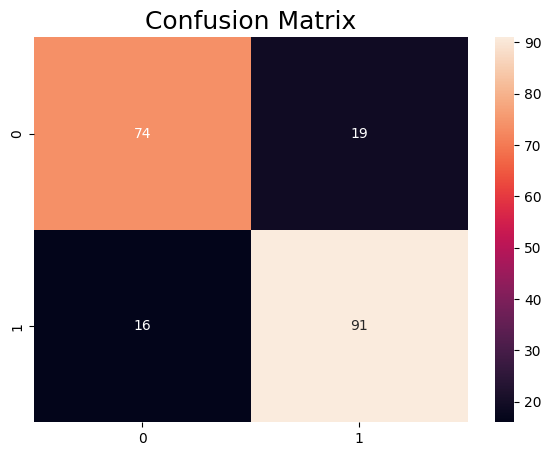

In [17]:
# Get the predictions from the classifier
y_pred = classifier.predict(X_test)

# Evaluate the classifier
class_report, conf_mat = evaluate_classification(y_test, y_pred)

# Exercise 5: "Availability of data"
---
**Goal.** Investigate how the amount of available training data affects the performance of the classification model.

**Methodology.**
1. We keep **the exact same train/test split** as in the baseline experiment above (`random_state=100`). The test set is *never* modified or re-sampled, so any performance difference is caused purely by the amount of training data, not by a different test set.
2. We record the model's performance on the **full, unmodified training set** as the baseline (this is the model trained and evaluated above, i.e. the 100% point).
3. We iterate over a list of percentages (1%, 2%, 5%, 10%, 20%, 50%, 100%) of the **original training set**. For each percentage we randomly select that percentage of rows from the original training set and train the model with only those rows.
4. Because a single random draw can be lucky or unlucky (especially for very small subsets), we **repeat each percentage 50 times with different randomly selected rows** and report the mean together with min/max error bars. This makes the trend reliable and reproducible.
5. The **actual number of training examples** used for each percentage is documented in a table below.
6. Training and evaluation are done exactly as in the baseline (GaussianNB, same input features, same metrics).

In [18]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# ------------------------------------------------------------------
# Baseline: performance of the model trained on 100% of the training
# data (this is the unmodified model trained and evaluated above).
# ------------------------------------------------------------------
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Original training set size : {len(X_train)} rows")
print(f"Test set size (fixed)      : {len(X_test)} rows")
print(f"Baseline accuracy  (100% of training data): {baseline_accuracy:.4f}")
print(f"Baseline macro F1  (100% of training data): {baseline_f1_macro:.4f}")

Original training set size : 466 rows
Test set size (fixed)      : 200 rows
Baseline accuracy  (100% of training data): 0.8250
Baseline macro F1  (100% of training data): 0.8237


### Helper functions
`train_and_score` trains a fresh Naive Bayes classifier and evaluates it on the **fixed** test set (same metrics as the baseline: accuracy and macro-averaged F1-score, which summarises precision and recall over both classes).

`sample_training_subset` randomly selects `n_rows` rows from the original training set. For very small subsets (e.g. 1% ≈ a handful of rows) a random draw can by chance contain only one class, and a classifier trained on a single class is degenerate (it can only ever predict that class). In that rare case we simply re-draw with a different seed; this is documented here for full reproducibility.

In [19]:
def train_and_score(X_tr, y_tr, X_te, y_te):
    '''Train a fresh GaussianNB on (X_tr, y_tr), evaluate on the fixed test set.'''
    model = GaussianNB()
    model.fit(X_tr, y_tr)
    y_hat = model.predict(X_te)
    return accuracy_score(y_te, y_hat), f1_score(y_te, y_hat, average='macro')


def sample_training_subset(X_tr, y_tr, n_rows, seed):
    '''Randomly select n_rows rows from the original training set.

    If the random draw happens to contain only one class (possible for very
    small subsets), re-draw with a shifted seed so that the model can be
    trained properly.'''
    for attempt in range(100):
        idx = X_tr.sample(n=n_rows, random_state=seed + 1000 * attempt).index
        if y_tr.loc[idx].nunique() >= 2:
            return X_tr.loc[idx], y_tr.loc[idx]
    raise RuntimeError("Could not draw a subset containing both classes.")

### The experiment
For each percentage we perform 10 repetitions, each with **different randomly selected rows** (a different random seed per percentage *and* per repetition). The test set stays untouched throughout.

In [20]:
# Percentages of the ORIGINAL TRAINING SET used for training
percentages = [1, 2, 5, 10, 20, 50, 100]
n_repeats = 50   # repetitions per percentage (different random rows each time)

results = []
for pct in percentages:
    # Actual number of training rows for this percentage (documented below).
    # We never go below 2 rows, since a model needs at least both classes.
    n_rows = max(2, int(round(pct / 100 * len(X_train))))

    accuracies, f1_scores = [], []
    for rep in range(n_repeats):
        # A unique seed per (percentage, repetition) guarantees different
        # randomly selected rows for every run, yet full reproducibility.
        seed = 97 * pct + rep
        X_sub, y_sub = sample_training_subset(X_train, y_train, n_rows, seed)
        acc, f1m = train_and_score(X_sub, y_sub, X_test, y_test)
        accuracies.append(acc)
        f1_scores.append(f1m)

    results.append({
        'percentage': pct,
        'n_training_rows': n_rows,
        'accuracy_mean': np.mean(accuracies),
        'accuracy_min': np.min(accuracies),
        'accuracy_max': np.max(accuracies),
        'f1_macro_mean': np.mean(f1_scores),
        'f1_macro_min': np.min(f1_scores),
        'f1_macro_max': np.max(f1_scores),
    })

results_df = pd.DataFrame(results)

# Documentation of the actual number of training examples per percentage
# (required for reproducibility) together with the evaluation results.
results_df.round(4)

,percentage,n_training_rows,accuracy_mean,accuracy_min,accuracy_max,f1_macro_mean,f1_macro_min,f1_macro_max
0,1,5,0.6179,0.465,0.830,0.5512,0.3174,0.8279
1,2,9,0.6660,0.470,0.810,0.6293,0.3354,0.8095
2,5,23,0.7382,0.605,0.850,0.7334,0.5965,0.8493
3,10,47,0.7694,0.615,0.870,0.7665,0.5251,0.8699
4,20,93,0.8059,0.710,0.860,0.8046,0.7090,0.8599
5,50,233,0.8336,0.810,0.850,0.8326,0.8084,0.8498
6,100,466,0.8250,0.825,0.825,0.8237,0.8237,0.8237


### Evaluation graph
The graph shows the mean performance over the 50 repetitions, with error bars spanning the minimum and maximum observed value. The dashed horizontal line is the **baseline** (the original model trained on 100% of the training data); the 100% point of the curve coincides with it, so all reduced-data results can be compared directly against the baseline. The x-axis is logarithmic because the percentages span two orders of magnitude.

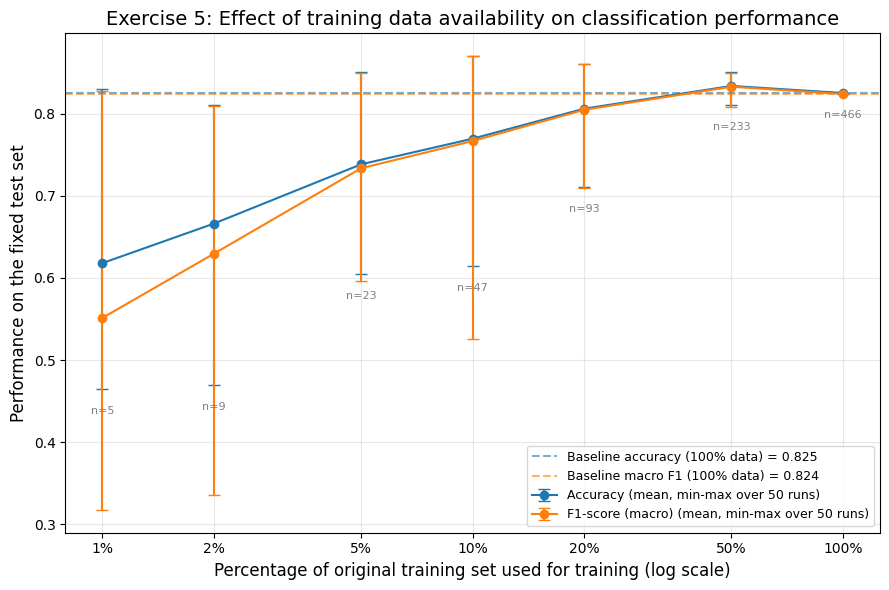

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

for metric, label, color in [('accuracy', 'Accuracy', 'tab:blue'),
                             ('f1_macro', 'F1-score (macro)', 'tab:orange')]:
    mean = results_df[f'{metric}_mean']
    # Clip at 0 to guard against tiny negative values from floating point
    # rounding (e.g. at the 100% point, where all repetitions are identical).
    yerr = np.clip(np.array([mean - results_df[f'{metric}_min'],
                             results_df[f'{metric}_max'] - mean]), 0, None)
    ax.errorbar(results_df['percentage'], mean, yerr=yerr,
                marker='o', capsize=4, color=color,
                label=f'{label} (mean, min-max over {n_repeats} runs)')

ax.axhline(baseline_accuracy, color='tab:blue', linestyle='--', alpha=0.6,
           label=f'Baseline accuracy (100% data) = {baseline_accuracy:.3f}')
ax.axhline(baseline_f1_macro, color='tab:orange', linestyle='--', alpha=0.6,
           label=f'Baseline macro F1 (100% data) = {baseline_f1_macro:.3f}')

ax.set_xscale('log')
ax.set_xticks(percentages)
ax.set_xticklabels([f'{p}%' for p in percentages])
ax.minorticks_off()

# Secondary annotation: absolute number of training rows per point
for _, row in results_df.iterrows():
    ax.annotate(f"n={int(row['n_training_rows'])}",
                (row['percentage'], row['accuracy_min']),
                textcoords='offset points', xytext=(0, -18),
                ha='center', fontsize=8, color='gray')

ax.set_xlabel('Percentage of original training set used for training (log scale)', fontsize=12)
ax.set_ylabel('Performance on the fixed test set', fontsize=12)
ax.set_title('Exercise 5: Effect of training data availability on classification performance',
             fontsize=14)
ax.grid(True, which='major', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()